<a href="https://colab.research.google.com/github/Revanth214214/Image_segmentation_UNI/blob/main/IMG_SEGMENTATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#start importing the libraries

import numpy as np
import matplotlib.pyplot as plt
import random
from pycocotools.coco import COCO
import skimage.io as io
from google.colab import drive

%matplotlib inline


In [2]:
#mount the drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#unzip the zip file in the drive

!unzip "/content/drive/MyDrive/RMDS_segmentation_dataset_ADE20K_350.zip" -d "/content/drive/MyDrive/ADE20K_350/"

Archive:  /content/drive/MyDrive/RMDS_segmentation_dataset_ADE20K_350.zip
  inflating: /content/drive/MyDrive/ADE20K_350/instances_train.json  
  inflating: /content/drive/MyDrive/ADE20K_350/__MACOSX/._instances_train.json  
  inflating: /content/drive/MyDrive/ADE20K_350/instances_val.json  
  inflating: /content/drive/MyDrive/ADE20K_350/__MACOSX/._instances_val.json  
   creating: /content/drive/MyDrive/ADE20K_350/test/
  inflating: /content/drive/MyDrive/ADE20K_350/__MACOSX/._test  
  inflating: /content/drive/MyDrive/ADE20K_350/test/ADE_val_00000242.jpg  
  inflating: /content/drive/MyDrive/ADE20K_350/__MACOSX/test/._ADE_val_00000242.jpg  
  inflating: /content/drive/MyDrive/ADE20K_350/test/ADE_val_00000531.jpg  
  inflating: /content/drive/MyDrive/ADE20K_350/__MACOSX/test/._ADE_val_00000531.jpg  
  inflating: /content/drive/MyDrive/ADE20K_350/test/ADE_val_00000647.jpg  
  inflating: /content/drive/MyDrive/ADE20K_350/__MACOSX/test/._ADE_val_00000647.jpg  
  inflating: /content/drive

In [5]:
# Define location of training data (images and labels).

train_data_path = "/content/drive/MyDrive/ADE20K_350"
train_annotation_file = f"{train_data_path}/instances_train.json"

In [6]:
# Initialising COCO API for instance annotations.

coco = COCO(train_annotation_file)

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


In [7]:
# Extract and display COCO categories and supercategories for the training dataset.

category_IDs = coco.getCatIds()
categories = coco.loadCats(category_IDs)

print(categories)

names_cats = [cats["name"] for cats in categories]
print(len(names_cats), "COCO categories:", " ".join(names_cats))


[{'id': 1, 'name': 'bed'}, {'id': 2, 'name': 'windowpane'}, {'id': 3, 'name': 'cabinet'}, {'id': 4, 'name': 'person'}, {'id': 5, 'name': 'door'}, {'id': 6, 'name': 'table'}, {'id': 7, 'name': 'curtain'}, {'id': 8, 'name': 'chair'}, {'id': 9, 'name': 'car'}, {'id': 10, 'name': 'painting'}, {'id': 11, 'name': 'sofa'}, {'id': 12, 'name': 'shelf'}, {'id': 13, 'name': 'mirror'}, {'id': 14, 'name': 'armchair'}, {'id': 15, 'name': 'seat'}, {'id': 16, 'name': 'fence'}, {'id': 17, 'name': 'desk'}, {'id': 18, 'name': 'wardrobe'}, {'id': 19, 'name': 'lamp'}, {'id': 20, 'name': 'bathtub'}, {'id': 21, 'name': 'railing'}, {'id': 22, 'name': 'cushion'}, {'id': 23, 'name': 'box'}, {'id': 24, 'name': 'column'}, {'id': 25, 'name': 'signboard'}, {'id': 26, 'name': 'chest of drawers'}, {'id': 27, 'name': 'counter'}, {'id': 28, 'name': 'sink'}, {'id': 29, 'name': 'fireplace'}, {'id': 30, 'name': 'refrigerator'}, {'id': 31, 'name': 'stairs'}, {'id': 32, 'name': 'case'}, {'id': 33, 'name': 'pool table'}, {'i

In [8]:
# Define function to extract category name from ID.

def get_category_name(class_ID, categories):
    for i in range(len(categories)):
        if categories[i]["id"] == class_ID:
            return categories[i]["name"]
    return "None"

In [9]:
# Look at one example.

category_name_10 = get_category_name(10, categories)
print(f"The category name is {category_name_10}.")

# Make sure to check out some others.

The category name is painting.


In [10]:
# Get all training images containing a given object category or categories.
# Remember, for this assignment we will focus on the classes "person", "car", "book", "airplane"!

filter_class = ["airplane"]
category_IDs = coco.getCatIds(catNms=filter_class)
image_IDs = coco.getImgIds(catIds=category_IDs)

print(f"Number of images containing specified category(ies): {len(image_IDs)}.")
print(f"IDs of images containing specified category(ies): {image_IDs}.")

# What happens when you are filtering for a different category or multiple classes?

Number of images containing specified category(ies): 5.
IDs of images containing specified category(ies): [21952, 20240, 20213, 21212, 21214].


{'file_name': 'ADE_val_00001743.jpg', 'width': 512, 'id': 21952, 'height': 768}


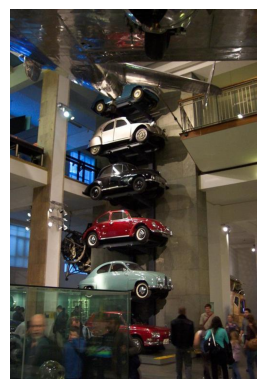

In [11]:
# Load and display one of the example images.

example_image = coco.loadImgs(image_IDs[0])[0]
print(example_image)

image = io.imread(f'{train_data_path}/train/{example_image["file_name"]}')
plt.axis("off")
plt.imshow(image)

plt.show()

In [12]:
# Get COCO annotation IDs and content of annotations, i.e., bounding boxes and segmentation masks.

test_image_annotations_ID = coco.getAnnIds(
    imgIds=example_image["id"], catIds=category_IDs, iscrowd=None
)
print(test_image_annotations_ID)

test_image_annotations = coco.loadAnns(test_image_annotations_ID)
print(test_image_annotations)

# Make sure you understand the content of the annotations.

[19547]
[{'id': 19547, 'image_id': 21952, 'segmentation': {'size': [768, 512], 'counts': 'P`1d2\\e03M1O1O1O0000002N00001O1O0000001O001O001O001O0000001O004L001O002N0000001O1O1O001O00001O1O1O001O00001O1O1O001O001O001O001O1O00001O1O001O1O0000001O001O001O001O00001O001O001O001O00001O001O001O001O0000001O1O001O1O0000001O001O001O001O00001O00001O1O001O0000001O1O001O001O0000001O1O001O001O00001O001O001O001O0000001O001O1O001O0000001O1O001O001O0000001O1O00001O1O00001O0000001O001O00001O000000001O001O0000001O001O00000000000000000000000000000000O1O100O100O10000O1O100L4K5G9L40000000000001O000000001OcNm\\OmMSc0S2m\\OmMSc0R2n\\OnMRc0R2o\\OmMQc0S2o\\OmMQc0S2o\\OmMQc0S2P]OmMob0S2Q]OmMPc0R2P]OnMPc0R2P]OnMPc0R2P]OnMPc0R2P]OnMPc0R2P]OoMob0Q2Q]OoMob0Q2R]OnMnb0R2R]OnMnb0R2R]OnMnb0R2S]OmMmb0S2S]OmMmb0S2S]OmMmb0S2T]OlMlb0T2T]OlMlb0T2T]OlMlb0T2T]OlMlb0T2U]OkMkb0U2U]OkMkb0U2U]OkMkb0U2U]OlMjb0T2V]OlMjb0T2V]OlMjb0T2W]OkMib0U2W]OkMib0U2W]OkMib0U2W]OkMib0U2X]OjMhb0V2X]OkMgb0U2Y]OkMgb0U2Y]OkMgb0U2Z]OjMfb0V2Z]OjMfb0V2Z]O

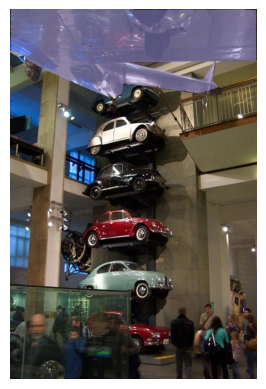

In [13]:
# Load and display test image with instance annotations.

plt.imshow(image)
plt.axis("off")

coco.showAnns(test_image_annotations)



In [14]:
# Extract the training images that contain any combination of the four target classes.

target_classes = ["person", "car", "book", "airplane"]
target_classes_IDs = coco.getCatIds(catNms=target_classes)
training_images = []

# Iterate over each individual class in the list.
for class_name in target_classes:
    # Get all images containing target class.
    print(class_name)
    training_images_categories = coco.getCatIds(catNms=class_name)
    training_images_IDs = coco.getImgIds(catIds=training_images_categories)
    training_images += coco.loadImgs(training_images_IDs)

print(
    f"Number of images with target classes including repetitions: {len(training_images)}."
)

person
car
book
airplane
Number of images with target classes including repetitions: 437.


In [15]:
# Filter out repeated images.

unique_training_images = []

for i in range(len(training_images)):
    if training_images[i] not in unique_training_images:
        unique_training_images.append(training_images[i])

# Shuffle the training data.
random.seed(0)
random.shuffle(unique_training_images)

print(
    f"Number of unique images in training data containing the target classes: {len(unique_training_images)}"
)

# Do you understand why the numbers are different?

Number of unique images in training data containing the target classes: 350


{'file_name': 'ADE_val_00000786.jpg', 'width': 683, 'id': 20995, 'height': 512}


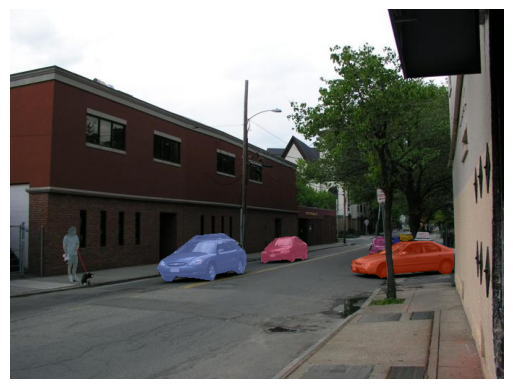

In [16]:
# Load and display example training image with segmentation masks.

training_image = unique_training_images[10]
print(training_image)

image = io.imread(f'{train_data_path}/train/{training_image["file_name"]}')
plt.axis("off")
plt.imshow(image)

training_image_annotations_ID = coco.getAnnIds(
    imgIds=training_image["id"], catIds=target_classes_IDs, iscrowd=None
)
training_image_annotations = coco.loadAnns(training_image_annotations_ID)
coco.showAnns(training_image_annotations, draw_bbox=False)

plt.show()

In [17]:
# To generate segmentation mask use annToMask function and extract the info stored in the annotations.
# For example, for the first object in our example training image:

mask_example = coco.annToMask(training_image_annotations[0])

print(type(mask_example))
print(mask_example)
print(mask_example.shape)
print(np.max(mask_example))
print(np.min(mask_example))

<class 'numpy.ndarray'>
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
(512, 683)
1
0


Unique pixel values in the mask: [2. 4. 5.]


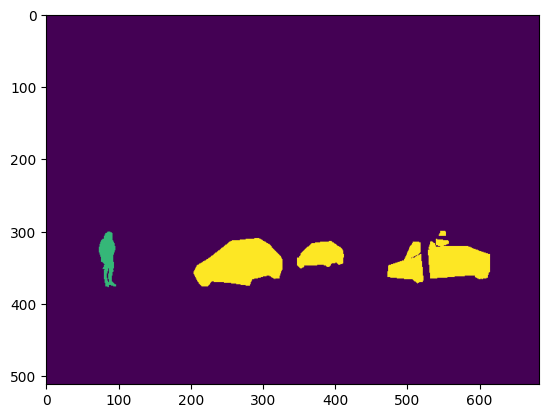

In [18]:
# Plotting the segmentation masks with different colours.
# There are many ways to do this. This is just one example.

mask = np.zeros((training_image["height"], training_image["width"]))

for i in range(len(training_image_annotations)):
    # Get object category name.
    object_category = get_category_name(
        training_image_annotations[i]["category_id"], categories
    )
    # Assign pixel value based on location in target_classes list.
    pixel_value = target_classes.index(object_category) + 1
    # Assign pixel value to mask based on annToMask output.
    mask = np.maximum(coco.annToMask(training_image_annotations[i]) * 3 + pixel_value, mask)

print(f"Unique pixel values in the mask: {np.unique(mask)}")

plt.imshow(mask)
plt.show()

# Do you understand the output of the print statement?
# Why did we have to add a + 1 in the defintion of the pixel_value?